# Notebook based on a BONUS question from stage 3  KAUST AI program (2025)

# BONUS Question
Solving this question gets you 10 extra points that will be distributed across both your theory and practical exams!

In [ ]:
import os
import kagglehub
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# Download latest version
cats_dir = os.path.join(kagglehub.dataset_download("vekosek/cats-from-memes"), "cats_from_memes")

print("Path to dataset files:", cats_dir)

100%|██████████| 199M/199M [00:02<00:00, 74.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vekosek/cats-from-memes/versions/5/cats_from_memes


In [ ]:
# Download latest version
pepe_dir = os.path.join(kagglehub.dataset_download("tornikeonoprishvili/pepe-memes-dataaset"),"data")

print("Path to dataset files:", pepe_dir)

100%|██████████| 49.7M/49.7M [00:00<00:00, 71.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tornikeonoprishvili/pepe-memes-dataaset/versions/1/data


In [ ]:
def combine_image_paths(cats_path, pepe_path, num_pepe=50):
    image_paths = []

    # Add all paths from cats directory
    image_paths.extend([
        str(Path(cats_path) / f)
        for f in os.listdir(cats_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    # Get all pepe image paths first
    pepe_paths = [
        str(Path(pepe_path) / f)
        for f in os.listdir(pepe_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Randomly select num_pepe images from pepe paths
    selected_pepe = random.sample(pepe_paths, min(num_pepe, len(pepe_paths)))
    image_paths.extend(selected_pepe)

    print(f"Number of cat images: {len(image_paths) - len(selected_pepe)}")
    print(f"Number of pepe images: {len(selected_pepe)}")
    print(f"Total number of images: {len(image_paths)}")

    return image_paths

In [ ]:
combined_paths = combine_image_paths(cats_dir, pepe_dir)

Number of cat images: 2283
Number of pepe images: 50
Total number of images: 2333


In [ ]:
combined_paths[-5::]

['/root/.cache/kagglehub/datasets/tornikeonoprishvili/pepe-memes-dataaset/versions/1/data/001221_pepe_stuck_inside.jpg',
 '/root/.cache/kagglehub/datasets/tornikeonoprishvili/pepe-memes-dataaset/versions/1/data/001834_pepe_eating_soup.jpg',
 '/root/.cache/kagglehub/datasets/tornikeonoprishvili/pepe-memes-dataaset/versions/1/data/000374_pepe_snake_tongue.jpg',
 '/root/.cache/kagglehub/datasets/tornikeonoprishvili/pepe-memes-dataaset/versions/1/data/002060_pepe_answering_red_phone.jpg',
 '/root/.cache/kagglehub/datasets/tornikeonoprishvili/pepe-memes-dataaset/versions/1/data/000611_pepe_frogs_hanging_out_on_leafpad.jpg']

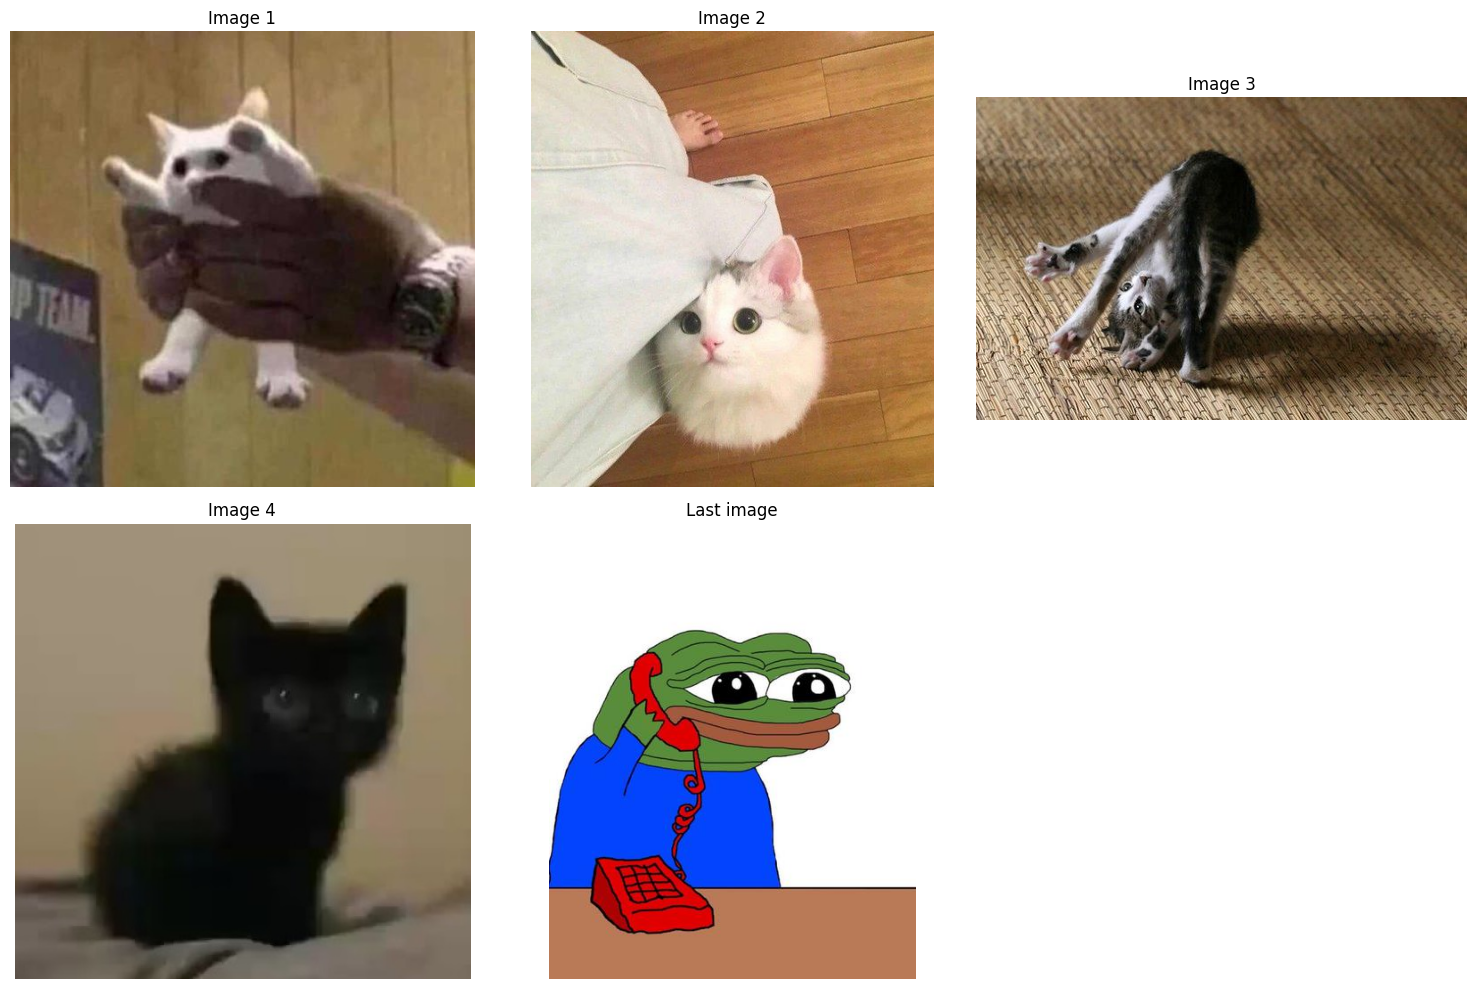

In [ ]:
def plot_sample_images(image_paths):
    # Create a figure with 5 subplots (2 rows, 3 columns)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Flatten axes for easier indexing
    axes = axes.flatten()

    # Plot first 4 images and the last image
    images_to_plot = image_paths[:4] + [image_paths[-2]]

    for idx, (img_path, ax) in enumerate(zip(images_to_plot, axes)):
        # Read and display image
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        # Add title indicating image position
        title = f"Last image" if idx == 4 else f"Image {idx+1}"
        ax.set_title(title)

    # Remove the last unused subplot
    axes[-1].remove()

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

# Use the function with your combined paths
plot_sample_images(combined_paths)


# Oh No!
A random Pepe has appeared! Can you train a model from scratch to detect them? After training the model, you need to plot the biggest outliers. How would you do that? It is up to you!

Tasks:
- Design a U-Net network from scratch that will be trained on reconstructing the images
- After training the autoencoder, you need to plot the total loss for all images after each epoch
- After training the autoencoder, you need to print the images as well as their reconstructed outputs
- You need to detect the *OUTLIERS*
    - The outliers are the Pepes. You can find outliers in multiple ways, including k-nearest neighbor or taking the average of all latent spaces and getting the ones that have a very low cosine similarity, or any other way you could think of!
- After detecting the outliers, you need to plot the highest 10 outliers. You get the 10 points if your autoencoder detected at least 1 Pepe out of all the images!
- Explain the reasoning behind your outlier detection approach. Show your understanding by explaining:
    - What method you chose for detecting outliers and why
    - How your method identifies what makes an image "abnormal"
    - How you determine the threshold for classifying an image as an outlier
    - Why your approach would be effective at detecting Pepe images 🫡
- Have fun and I hope to see you all in the summer!

In [ ]:
# Start your code here!

# Written by Ali Habibullah and Idea by Yazan Alshuaibi